# Recommender System Data Visualization
Exploring raw datasets and processed interaction matrices for the hybrid recommender.

## 1. Raw Data Exploration
Loading the raw `movies.csv`, `ratings.csv`, and `tags.csv` to understand their distributions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pickle

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Load raw data
movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags = pd.read_csv('../data/raw/tags.csv')

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)
print("Tags Shape:", tags.shape)


Movies Shape: (9742, 3)
Ratings Shape: (100836, 4)
Tags Shape: (3683, 4)


In [3]:
display(movies.head(3))
display(ratings.head(3))
display(tags.head(3))


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992


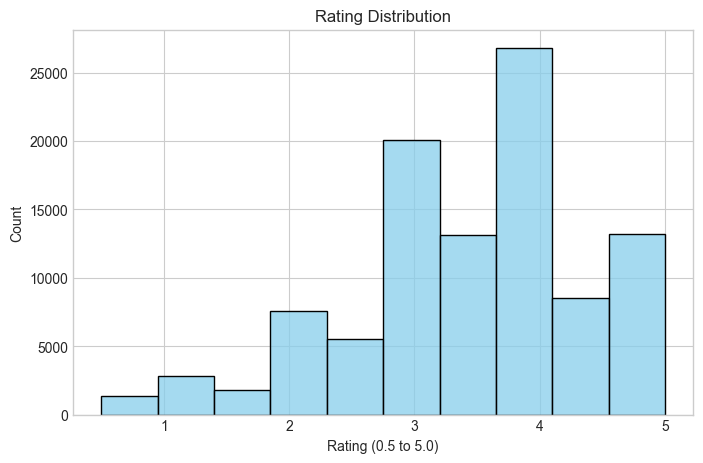

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings['rating'], bins=10, kde=False, color='skyblue')
plt.title('Rating Distribution')
plt.xlabel('Rating (0.5 to 5.0)')
plt.ylabel('Count')
plt.show()


C:\Users\siskebe\AppData\Local\Temp\ipykernel_6420\2270455400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies_df, y='title', x='count', palette='viridis')


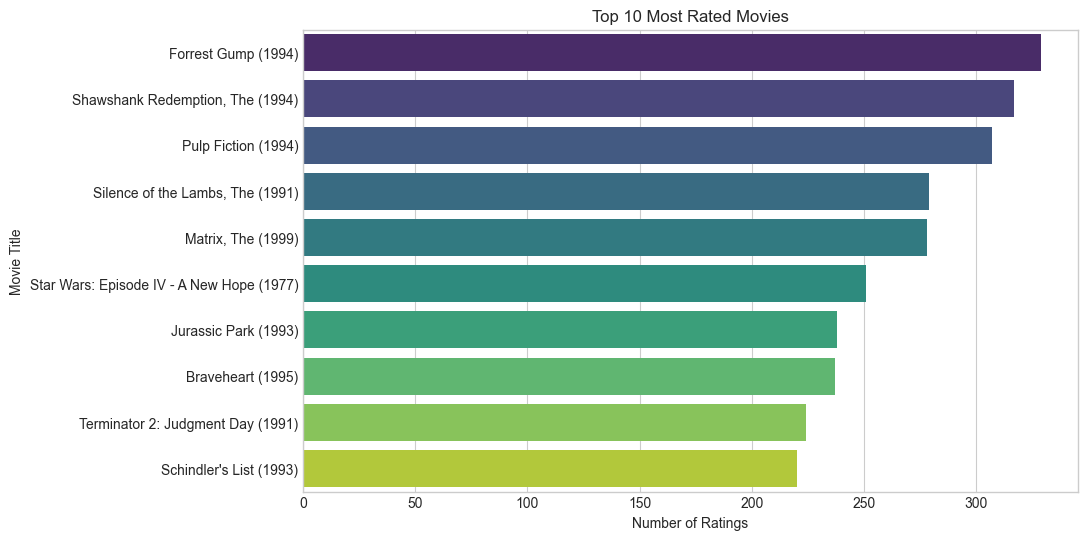

In [5]:
top_movies = ratings['movieId'].value_counts().head(10)
top_movies_df = top_movies.reset_index()
top_movies_df.columns = ['movieId', 'count']
top_movies_df = top_movies_df.merge(movies, on='movieId')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_movies_df, y='title', x='count', palette='viridis')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()


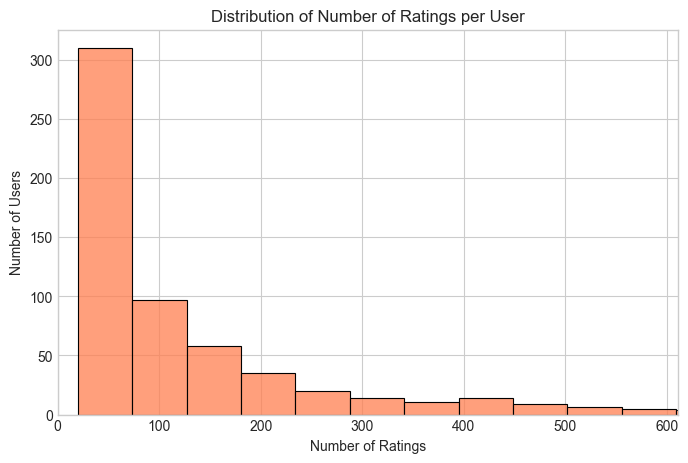

In [6]:
user_counts = ratings['userId'].value_counts()
plt.figure(figsize=(8, 5))
sns.histplot(user_counts, bins=50, color='coral')
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.xlim(0, user_counts.quantile(0.95)) # Zoom in on the majority
plt.show()


## 2. Processed Data
Loading the transformed outputs matching the internal interaction matrices and content pipelines.

In [7]:
content_movies = pd.read_csv('../data/preprocessed/content_movies.csv')
display(content_movies.head())


,movieId,title,content
0,1,Toy Story,adventure animation children comedy fantasy pi...
1,2,Jumanji,adventure children fantasy fantasy magic board...
2,3,Grumpier Old Men,comedy romance moldy old
3,4,Waiting to Exhale,comedy drama romance
4,5,Father of the Bride Part II,comedy pregnancy remake


Matrix Shape: (610, 3650)
Matrix Density: 3.24%
Matrix Sparsity: 96.76%


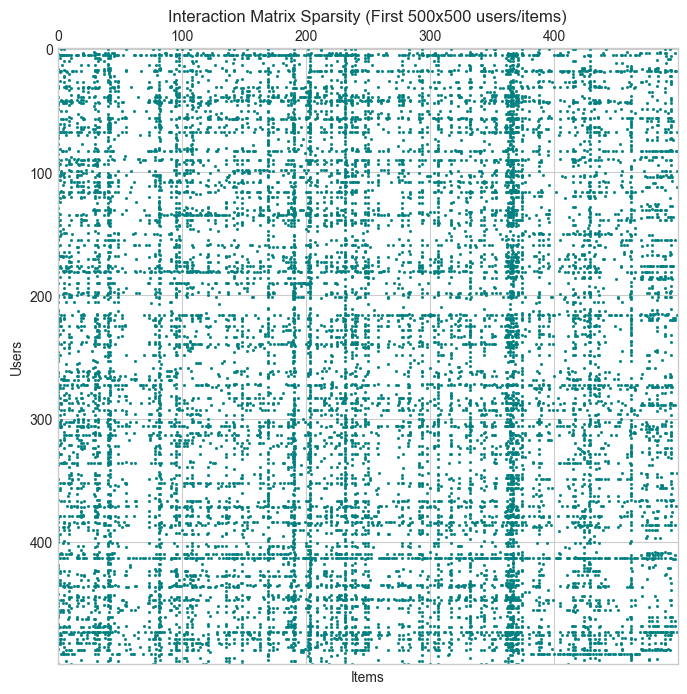

In [9]:
# Sparsity of user-item matrix
with open('../data/preprocessed/interaction_matrix_train.pkl', 'rb') as f:
    interaction_matrix = pickle.load(f)

density = (interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1])) * 100
print(f"Matrix Shape: {interaction_matrix.shape}")
print(f"Matrix Density: {density:.2f}%")
print(f"Matrix Sparsity: {100 - density:.2f}%")

# Plot a visual sample of the matrix (e.g. first 500x500 chunk)
subset = interaction_matrix[:500, :500].toarray()
plt.figure(figsize=(8, 8))
plt.spy(subset, markersize=1, aspect='auto', color='teal')
plt.title('Interaction Matrix Sparsity (First 500x500 users/items)')
plt.xlabel('Items')
plt.ylabel('Users')
plt.show()


C:\Users\siskebe\AppData\Local\Temp\ipykernel_6420\2195358512.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pop_df, y='title', x='score', palette='rocket')


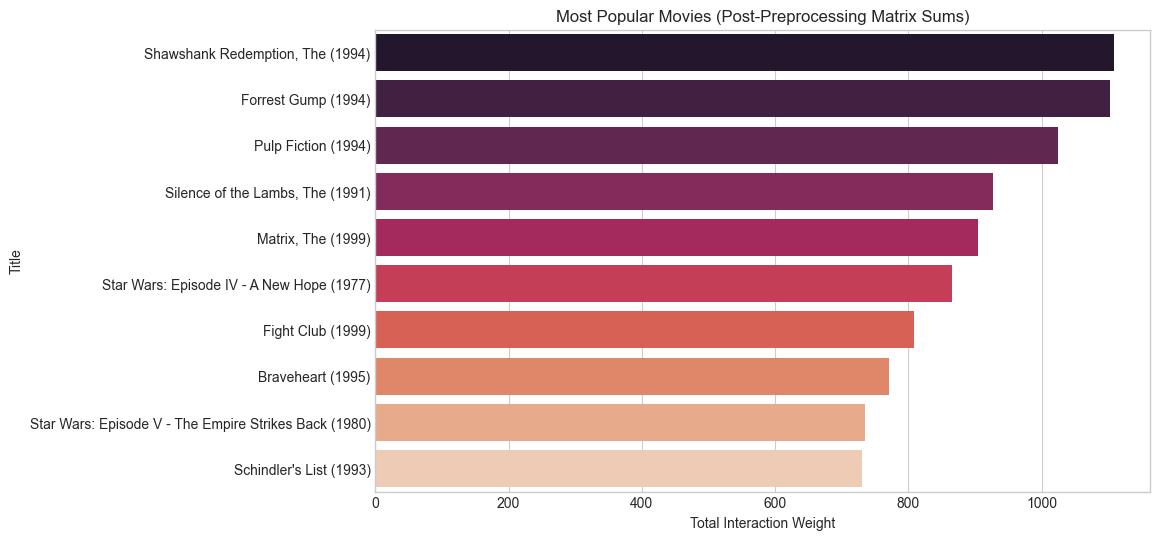

In [10]:
popularity = np.array(interaction_matrix.sum(axis=0)).ravel()
top_pop_indices = np.argsort(popularity)[::-1][:10]

with open('../data/preprocessed/movie_map.pkl', 'rb') as f:
    movie_map = pickle.load(f)
inv_movie_map = {v: k for k, v in movie_map.items()}

top_movie_ids = [inv_movie_map[idx] for idx in top_pop_indices]
pop_df = pd.DataFrame({
    'movieId': top_movie_ids,
    'score': popularity[top_pop_indices]
})
pop_df = pop_df.merge(movies, on='movieId')

plt.figure(figsize=(10, 6))
sns.barplot(data=pop_df, y='title', x='score', palette='rocket')
plt.title('Most Popular Movies (Post-Preprocessing Matrix Sums)')
plt.xlabel('Total Interaction Weight')
plt.ylabel('Title')
plt.show()
